## 🔥 <span style='text-decoration: double underline; color:rgb(10,110,217)'>**PyTorch: Training and Data Pipelines**</span>


### 📑  <span style='color:rgb(10,110,217)'><u>**Introduction**</u></span>

#### 🏗️ <span style='color:rgb(10,110,217)'><u>**Building Models with nn.Module**</u></span>

`nn.Module` is the cornerstone of every neural network in PyTorch. Any model — from a single linear layer to a transformer — must subclass it.

The minimal contract requires two things: defining learnable components in `__init__` and describing the forward computation in `forward()`.

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.layer(x)
```

When you call `model(x)`, PyTorch routes the call through `forward()` automatically, while also handling gradient hooks, device placement, and parameter tracking behind the scenes.

**Linear Regression** is the simplest possible model: a single `nn.Linear(1, 1)` layer, which learns two parameters — a weight `w` and a bias `b` — to fit `ŷ = wx + b`. The training loop follows a four-step cycle:

1. **Forward pass** — compute predictions
2. **Loss computation** — measure the error (e.g., MSE)
3. **Backward pass** — compute gradients via `loss.backward()`
4. **Parameter update** — apply `optimizer.zero_grad()`, then `optimizer.step()`. 


#### 📈 <span style='color:rgb(10,110,217)'><u>**Activation Functions**</u></span>

Activation functions introduce **non-linearity** into the network, enabling it to learn complex mappings beyond simple linear transformations. Without them, stacking multiple layers would be mathematically equivalent to a single linear layer. Some examples are:

<div align='center'>

| Activation | Formula | Key Properties |
|---|---|---|
| **ReLU** | `max(0, x)` | Simple, fast; suffers from *dying ReLU* for negative inputs |
| **Tanh** | `(eˣ − e⁻ˣ) / (eˣ + e⁻ˣ)` | Zero-centered output `(−1, 1)`; can vanish for large inputs |
| **GELU** | `x · Φ(x)` | Smooth, probabilistic gating; preferred in Transformers |
| **LeakyReLU** | `max(αx, x)` | Fixes dying ReLU by allowing small negative gradients |
</div>


#### 🌘 <span style='color:rgb(10,110,217)'><u>**Decision Boundaries**</u></span>

In classification problems, **decision boundaries** are the regions in feature space where the model's predicted class changes. They represents the limits the model has stablished to distinguish between classes. 

Visualizing them via a meshgrid of predictions reveals how well the MLP has carved the input space into class regions.

<div align='center'>
<img src="https://imgs.search.brave.com/KGUFJAitARuIC-gBXI2EpaNbWzY6uJuLouSxRmJf5sI/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9yb2hp/dG1pZGhhMjMuZ2l0/aHViLmlvL2Fzc2V0/cy9pbWFnZXMvTmV1/cmFsTmV0Qm91bmRh/cnkvZGVjaXNpb24t/Ym91bmRhcnkucG5n" alt="Decision boundaries" width="400">

</div>

#### 👮 <span style='color:rgb(10,110,217)'><u>**Inspecting Model Parameters**</u></span>

PyTorch tracks all `nn.Parameter` objects (and the parameters of submodules) automatically. Two key APIs:

- `model.named_parameters()` — iterates over `(name, tensor)` pairs for all learnable parameters
- `model.parameters()` — same, but without names; useful for passing to an optimizer

The total parameter count is:

```python
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
```

Visualizing weight matrices as heatmaps (e.g., with `matplotlib.imshow`) can reveal patterns such as structured sparsity or poor initialization — insights that raw numbers alone do not provide.

#### 💾 <span style='color:rgb(10,110,217)'><u>**Saving and Loading Models**</u></span>

PyTorch separates the **model architecture** (Python code) from the **learned weights** (a `state_dict`, i.e., an ordered dictionary of parameter tensors).

```python
# Save
torch.save(model.state_dict(), 'model.pth')

# Load into a new instance of the same architecture
model2 = MyModel()
model2.load_state_dict(torch.load('model.pth'))
model2.eval()
```

This design is intentional: weights are lightweight and portable; the architecture is defined in code and can be versioned independently. Using `torch.allclose()` to verify that two models produce identical outputs after loading confirms that no numerical drift occurred.

- **Note:** Always use `.pth` to save the model.

#### 🖌️ <span style='color:rgb(10,110,217)'><u>**Custom Layers and Learnable Parameters**</u></span>

Beyond the built-in layers, PyTorch allows you to define entirely new operations that participate in gradient computation. Any tensor wrapped in `nn.Parameter` is:

- Registered as a model parameter (visible via `.parameters()`)
- Included in optimizer updates
- Tracked by autograd

#### ♻️<span style='color:rgb(10,110,217)'><u>**Residual Connections (ResNets)**</u></span>

A **Residual Block** introduces a skip connection that adds the block's input directly to its output:

```
out = F(x) + x
```

where `F(x)` is a sequence of linear layers and activations. This seemingly small change solves two critical problems in deep networks:

**Vanishing gradients**: During backpropagation, gradients must pass through every layer. In deep networks, repeated multiplication by small numbers causes the gradient to shrink exponentially. Skip connections provide an unobstructed gradient highway directly to earlier layers.

**Degradation problem**: Empirically, simply adding more layers to a plain network can *hurt* performance, even on training data. With residual connections, deeper networks can always fall back to the identity function (`F(x) ≈ 0`), guaranteeing that adding depth never makes things worse.

The key insight is that **learning a residual `F(x) = H(x) − x` is easier than learning the full mapping `H(x)` from scratch**, especially when the optimal function is close to the identity.

<div align='center'>
<img src="https://imgs.search.brave.com/GK5ZWgwQdzf4rH-krwOrDokh7barX0iVDRlNZ1BjJ9g/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly91cGxv/YWQud2lraW1lZGlh/Lm9yZy93aWtpcGVk/aWEvY29tbW9ucy90/aHVtYi9iL2JhL1Jl/c0Jsb2NrLnBuZy8x/MjgwcHgtUmVzQmxv/Y2sucG5n" alt="Decision boundaries" width="400">

</div>


#### 🎊 <span style='color:rgb(10,110,217)'><u>**Weight Initialization**</u></span>

How parameters are initialized before training profoundly affects whether and how fast a network learns. Poor initialization causes two classic failure modes:

- **Symmetry breaking problem (all-zeros)**: If all weights are initialized to zero, every neuron in a layer computes the same function, receives the same gradient, and updates identically — effectively collapsing the layer to a single neuron. The network cannot break this symmetry through gradient descent alone.

There are different ways of initialization weights. For example:

- **Xavier (Glorot) initialization**: Designed for saturating activations like Tanh and Sigmoid. Scales weights so that the **variance of activations and gradients is preserved** across layers:

$$
W \approx \text{Uniform}(−\sqrt{\frac{6}{(n_{in} + n_{out})}}, \sqrt{\frac{6}{(n_{in} + n_{out})}})
$$

The goal is to prevent activations from vanishing (too small) or exploding (too large) as the signal propagates forward and the gradient propagates backward.

- **Kaiming (He) initialization**: Designed specifically for **ReLU-family activations**, which discard roughly half of all activations (the negative half). Xavier's variance calculation assumes a symmetric, linear activation, so it underestimates the effective fan-in for ReLU. Kaiming corrects for this:

$$
W \approx  \text{Normal}(0, \sqrt{\frac{2}{n_{in}}})
$$

The factor of 2 compensates for the halving effect of ReLU.

- <span style='color:rgb(188, 7, 194)'>**Rule of thumb**:</span> Use Xavier for Tanh/Sigmoid; use Kaiming for ReLU, LeakyReLU, and GELU.

---

### 🦉 <span style='color:rgb(10,110,217)'><u>**Level 2: Seeing through the layers**</u></span>
Use the [official documentation](https://docs.pytorch.org/docs/stable/index.html) while solving the exercises.

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 1:**</span>

> Build a simple linear regression model using `nn.Module` from scratch. Define a class `LinearRegression` with one `nn.Linear(1, 1)` layer. Generate synthetic data following `y = 4x + 3 + noise` with 100 points. Train for 400 epochs using `MSELoss` and `SGD`. After training, verify that the learned weight is close to **4** and the bias close to **3**.
- **Hint:** 
    - Architecture: 1 → Linear(1,1) → 1
    - Loss:         `nn.MSELoss`
    - Optimizer:    `torch.optim.SGD`

I won't use here `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)` because the gradients won't explode. The general rule of use is to use it when the loss explodes. That would be an extra-hyperparameter in our model.

In [1]:
import torch 
import torch.nn as nn

# Model:
class LinearRegression(nn.Module):
    # Builder of the model:
    def __init__(self):
        super().__init__()
        self.LinearLayer = nn.Linear(1,1)
    
    def forward(self, x):
        return self.LinearLayer(x)

# Create model:
model = LinearRegression()

# Data:
torch.manual_seed(42)
x = torch.rand(100,1)
noise = torch.randn(100,1) * 0.1
y = 4*x + 3 + noise

# Loss and optimizer:
learning_rate = 0.1

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Train:
epochs = 400
losses = []

print('Starting training...')
for epoch in range(epochs):

    # Zero_grad the optimizer:
    optimizer.zero_grad()
    loss = loss_fn(model(x), y)

    # Backpropagation:
    loss.backward()

    # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Optional

    optimizer.step()
    losses.append(loss.item())
    if epoch % 25 == 0 or epoch == epochs - 1 :
            print(f'Epoch {epoch} ----->  Loss: {loss.item():.4f}')

print('-----' * 10)
# Parameters:
weight = model.LinearLayer.weight.item()
bias   = model.LinearLayer.bias.item()
print(f'Weight learned: {weight:.4f}  (expected ≈ 4)')
print(f'Bias learned:   {bias:.4f}  (expected ≈ 3)')

Starting training...
Epoch 0 ----->  Loss: 29.0533
Epoch 25 ----->  Loss: 0.0822
Epoch 50 ----->  Loss: 0.0452
Epoch 75 ----->  Loss: 0.0263
Epoch 100 ----->  Loss: 0.0167
Epoch 125 ----->  Loss: 0.0118
Epoch 150 ----->  Loss: 0.0092
Epoch 175 ----->  Loss: 0.0080
Epoch 200 ----->  Loss: 0.0073
Epoch 225 ----->  Loss: 0.0070
Epoch 250 ----->  Loss: 0.0068
Epoch 275 ----->  Loss: 0.0067
Epoch 300 ----->  Loss: 0.0067
Epoch 325 ----->  Loss: 0.0067
Epoch 350 ----->  Loss: 0.0066
Epoch 375 ----->  Loss: 0.0066
Epoch 399 ----->  Loss: 0.0066
--------------------------------------------------
Weight learned: 3.9478  (expected ≈ 4)
Bias learned:   3.0264  (expected ≈ 3)


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 2:**</span>

> Train the same MLP architecture four times on `y = sin(x)` (300 evenly spaced points, `x ∈ [-π, π]`), changing **only** the activation function each time: `ReLU`, `Tanh`, `GELU` and `LeakyReLU`. The activation is applied after each hidden layer; the output layer has none.
>
>Plot the four loss curves on the same graph and the four learned functions vs. the real sine curve. Which activation fits the sine shape best, and why?

- **Architecture:** `Linear(1→32) → Act → Linear(32→16) → Act → Linear(16→1)`
- **Loss:** `nn.MSELoss`
- **Optimizer:** `Adam (lr=1e-3)`
- **Epochs:** `500`
- **Batch:** full-batch (all 300 points per step)

In [ ]:
# Model:
torch.manual_seed(42)
class Model(nn.Module):

    def __init__(self, activation=nn.ReLU):
        super().__init__()
        blocks = []
        neurons = [(1,32), (32,16)]
        for _ in range(2):
            n_in, n_out = neurons[_]
            blocks.extend([nn.Linear(n_in, n_out), activation()])
        
        self.blocks = nn.Sequential(*blocks)
        self.output = nn.Linear(16,1)
    
    def forward(self, x):
        x = self.blocks(x)
        return self.output(x)

# Data:
x = torch.linspace(-torch.pi, torch.pi, 300).unsqueeze(1) # (300, 1)
y = torch.sin(x) # (300,1)

# Configs:
configs = {'ReLU': nn.ReLU, 'Tanh': nn.Tanh, 
           'GELU': nn.GELU, 'LeakyReLU': nn.LeakyReLU}

epochs = 500
results = {}
for key, activation_function in configs.items():
    
    model = Model(activation= activation_function)
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
    loss_fn = nn.MSELoss()
    losses = []
    print(f'Starting {key} training...')
    model.train()
    for epoch in range(epochs):
        
        optimizer.zero_grad()

        loss = loss_fn(model(x), y)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0 or epoch == epochs-1:

            print(f'Epoch {epoch} ---> Loss: {loss.item()}')

        losses.append(loss.item())

    results[key] = {'losses': losses, 'model': model}
    print('-----'*10)

Starting ReLU training...
Epoch 0 ---> Loss: 0.5030925869941711
Epoch 100 ---> Loss: 0.10790500789880753
Epoch 200 ---> Loss: 0.04407544806599617
Epoch 300 ---> Loss: 0.013190364465117455
Epoch 400 ---> Loss: 0.004388445056974888
Epoch 499 ---> Loss: 0.001769070397131145
--------------------------------------------------
Starting Tanh training...
Epoch 0 ---> Loss: 0.48216161131858826
Epoch 100 ---> Loss: 0.08473459631204605
Epoch 200 ---> Loss: 0.03545720502734184
Epoch 300 ---> Loss: 0.020817823708057404
Epoch 400 ---> Loss: 0.011727229692041874
Epoch 499 ---> Loss: 0.005883519072085619
--------------------------------------------------
Starting GELU training...
Epoch 0 ---> Loss: 0.8635809421539307
Epoch 100 ---> Loss: 0.0876428484916687
Epoch 200 ---> Loss: 0.017983855679631233
Epoch 300 ---> Loss: 0.007721055299043655
Epoch 400 ---> Loss: 0.0031852973625063896
Epoch 499 ---> Loss: 0.0012849830090999603
--------------------------------------------------
Starting LeakyReLU training.

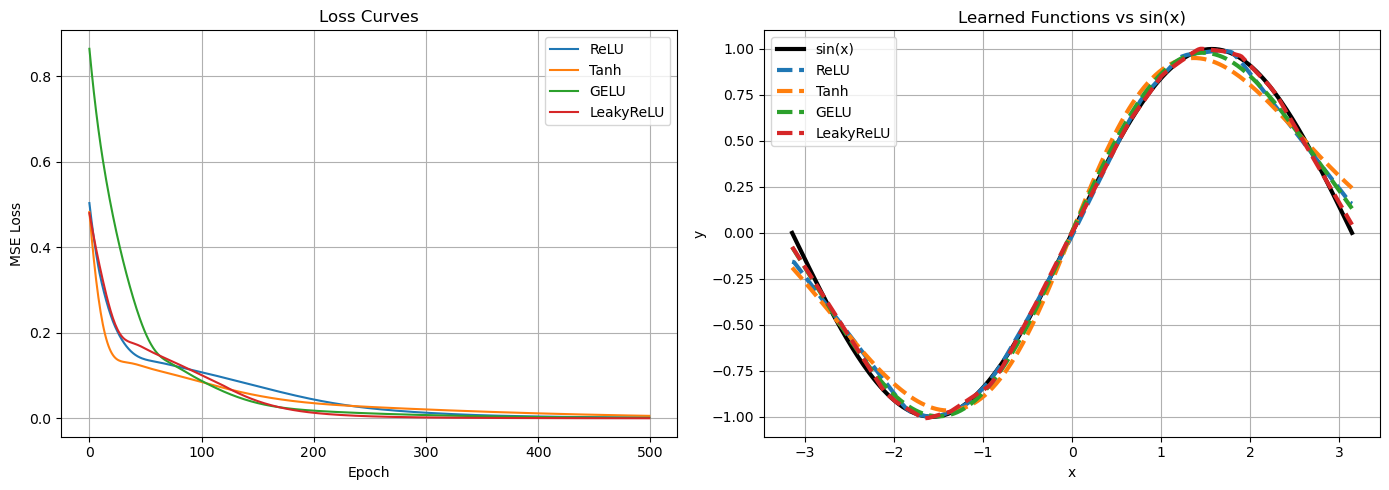

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Loss curves
for key, data in results.items():
    axes[0].plot(data['losses'], label=key)
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2 — Learned functions vs sin(x)
axes[1].plot(x.numpy(), y.numpy(), color='black', linewidth=3, label='sin(x)', alpha=1)
for key, data in results.items():
    model = data['model']
    model.eval()
    
    with torch.no_grad():
        y_pred = model(x).numpy()
    axes[1].plot(x.numpy(), y_pred, label=key, linestyle='--', linewidth=3)

axes[1].set_title('Learned Functions vs sin(x)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 3:**</span>
> Generate a synthetic 3-class dataset in 2D with `sklearn.datasets.make_blobs(300 samples, centers=3, cluster_std=1.2, random_state=42)`. Split it
> 80/20 into train/test (`random_state=42`). Build and train a MLP, then:
>
> - Print the final **accuracy** on the test set
> - Plot the **decision boundaries** as a `plt.contourf` colored background
>   (meshgrid step `0.1`, margin `0.5` beyond data range) with the test points
>   overlaid as a scatter plot

- **Architecture:** `Linear(2→16) → ReLU → Linear(16→8) → ReLU → Linear(8→3)`
- **Loss:** `nn.CrossEntropyLoss` (expects raw logits — no activation on output layer)
- **Optimizer:** `Adam (lr=1e-3)`
- **Epochs:** `300`
- **Batch:** full-batch (all training points per step)
- **Tensors:** `X` → `FloatTensor`, `y` → `LongTensor`

--- Complete dataset ---
x.shape: (300, 2)
y.shape: (300,)
Classes: {np.int64(0), np.int64(1), np.int64(2)}
--- Train dataset ---
x_train.shape: (240, 2)
y_train.shape: (240,)
--- Test dataset ---
x_test.shape: (60, 2)
y_test.shape: (60,)


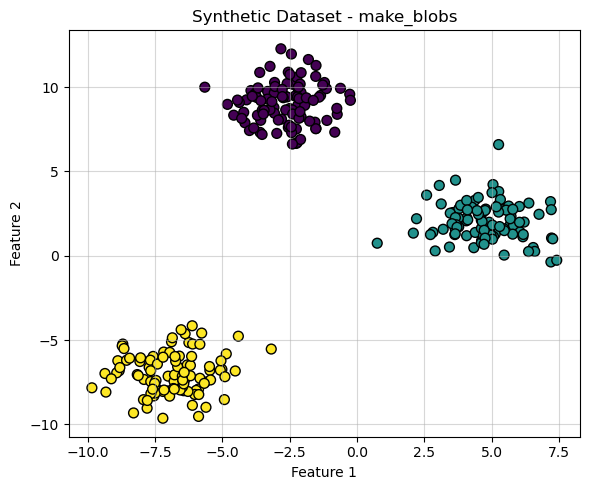

In [4]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
# Generate dataset:
x, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=1.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

print('--- Complete dataset ---')
print(f'x.shape: {x.shape}')
print(f'y.shape: {y.shape}')
print(f'Classes: {set(y)}')
print('--- Train dataset ---')
print(f'x_train.shape: {x_train.shape}')
print(f'y_train.shape: {y_train.shape}')
print('--- Test dataset ---')
print(f'x_test.shape: {x_test.shape}')
print(f'y_test.shape: {y_test.shape}')

plt.figure(figsize=(6,5))
plt.grid(True, alpha=0.5)
plt.scatter(x[:,0],  x[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)
plt.title('Synthetic Dataset - make_blobs')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Create the model:
model = nn.Sequential(nn.Linear(2,16), nn.ReLU(),
                      nn.Linear(16,8), nn.ReLU(),
                      nn.Linear(8,3))
# Transforming data:
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

x_test = torch.FloatTensor(x_test)
y_test = torch.LongTensor(y_test)

# Loss and optimizer:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop:
epochs = 300
losses, accuracies = [], []
model.train()

print('--- Train ---')
for epoch in range(epochs):
    # Reset optimizer:
    optimizer.zero_grad()
    logits = model(x_train)
    # Compute loss:
    loss = loss_fn(logits, y_train)

    # Compute Metrics:
    with torch.no_grad():
        preds = logits.argmax(dim=1).numpy()
        accuracy = accuracy_score(y_train.numpy(), preds)

    # Backprop:
    loss.backward()
    optimizer.step()

    if (epoch % 50 == 0) or (epoch == epochs -1):
        print(f'Epoch {epoch} ---> Loss: {loss.item():.4f} ; accuracy: {accuracy:.4f}')
    
    losses.append(loss.item())
    accuracies.append(accuracy)

model.eval()
# Test:
with torch.no_grad():
    y_pred = model(x_test)
    loss_test = loss_fn(y_pred, y_test)
    accuracy_test = accuracy_score(y_test, y_pred.argmax(dim=1).numpy())
    
print('--- Test ---')
print(f'Loss: {loss_test.item():.4f}')
print(f'Accuracy: {accuracy_test:.4f}')
print('-----'*10)

--- Train ---
Epoch 0 ---> Loss: 1.0101 ; accuracy: 0.3333
Epoch 50 ---> Loss: 0.6699 ; accuracy: 0.6667
Epoch 100 ---> Loss: 0.4351 ; accuracy: 0.9375
Epoch 150 ---> Loss: 0.2124 ; accuracy: 0.9917
Epoch 200 ---> Loss: 0.0975 ; accuracy: 1.0000
Epoch 250 ---> Loss: 0.0486 ; accuracy: 1.0000
Epoch 299 ---> Loss: 0.0276 ; accuracy: 1.0000
--- Test ---
Loss: 0.0270
Accuracy: 1.0000
--------------------------------------------------


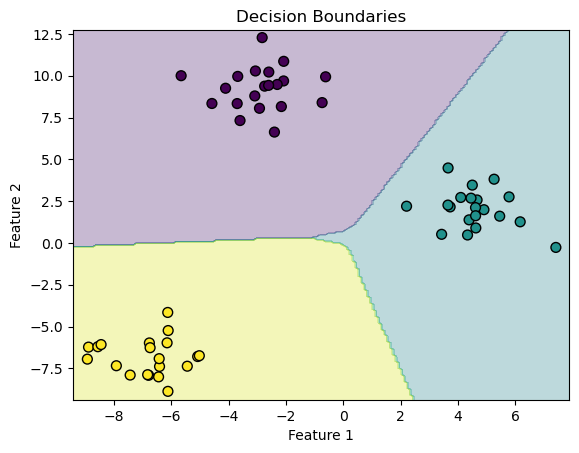

In [6]:
import numpy as np

# plt.contourf:

# Range --> Axis OX 
min_feature1 = x_test[:,0].min().item() - 0.5
max_feature1 = x_test[:,0].max().item() + 0.5
x_min, x_max = min_feature1, max_feature1

# Range --> Axis OY
min_feature2 = x_test[:,1].min().item() - 0.5
max_feature2 = x_test[:,1].max().item() + 0.5
y_min, y_max = min_feature2, max_feature2

# Create a grid with all possible combination:
feature1_pnt = np.arange(x_min, x_max, 0.1)
feature2_pnt = np.arange(y_min, y_max, 0.1)
xx, yy = np.meshgrid(feature1_pnt, feature2_pnt)

# Transform the grid as if it were the input of the model
grid_stack = np.column_stack([xx.ravel(), yy.ravel()])
grid = torch.FloatTensor(grid_stack)  # shape (H*W, 2)

# Evaluate the model:
model.eval()
with torch.no_grad():
    Z = model(grid).argmax(dim=1).numpy()  # shape (H*W,)

Z = Z.reshape(xx.shape)  # shape (H, W)

plt.title('Decision Boundaries')
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test.numpy(), 
            cmap='viridis', edgecolors='k', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 4:**</span>

> Define a MLP with `nn.Sequential` and inspect its parameters **without
> using any external library**:
>
> 1. Print the name and shape of every parameter using `model.named_parameters()`
> 2. Count the **total number of trainable parameters** with `sum(p.numel() for p in model.parameters())`
> 3. Visualize the weight matrix of the first layer as a **heatmap** using
>    `plt.imshow` with `cmap='viridis'` and a colorbar

- **Architecture:** `Linear(4→16) → ReLU → Linear(16→8) → ReLU → Linear(8→3)`
- **No training needed** — just instantiate the model with default (random) weights

Name: 0.weight --> Parameter: torch.Size([16, 4])
Name: 0.bias --> Parameter: torch.Size([16])
Name: 2.weight --> Parameter: torch.Size([8, 16])
Name: 2.bias --> Parameter: torch.Size([8])
Name: 4.weight --> Parameter: torch.Size([3, 8])
Name: 4.bias --> Parameter: torch.Size([3])
Total number of trainable parameters: 243


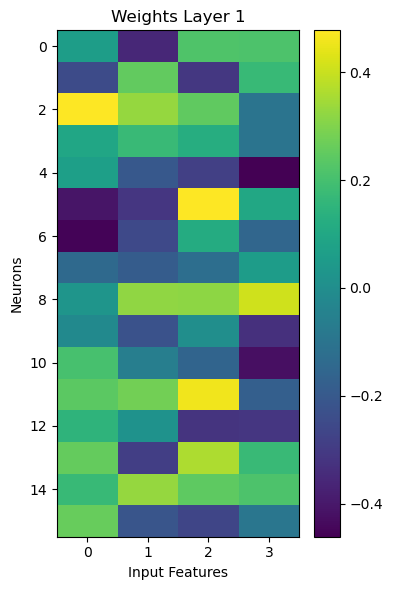

In [7]:
# Create model:
model = nn.Sequential(nn.Linear(4,16), nn.ReLU(),
                      nn.Linear(16,8), nn.ReLU(),
                      nn.Linear(8,3))
# Names:
for name, parameter in model.named_parameters():
    print(f'Name: {name} --> Parameter: {parameter.shape}')

# Number of weights:
total = sum(p.numel() for p in model.parameters())
print(f'Total number of trainable parameters: {total}')

# Heatmap first layer:
weights1 = model[0].weight.detach().numpy() # Shape (16,4) --> 4 inputs, 16 neurons
plt.figure(figsize=(4,6))
plt.imshow(weights1, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Weights Layer 1')
plt.xlabel('Input Features')
plt.ylabel('Neurons')
plt.tight_layout()
plt.show()


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 5:**</span>

> Train a MLP classifier on the Iris dataset (`sklearn.datasets.load_iris`,
> 150 samples, 4 features, 3 classes). Once trained:
>
> 1. Save the model weights with `torch.save(model.state_dict(), 'iris_model.pth')`
> 2. Create a **new instance** of the same architecture and load the saved weights
>    with `model.load_state_dict(torch.load('iris_model.pth'))`
> 3. Run both models in `model.eval()` + `torch.no_grad()` on the test set
> 4. Verify the outputs are **identical** with `torch.allclose(out1, out2)`

- **Architecture:** `Linear(4→16) → ReLU → Linear(16→8) → ReLU → Linear(8→3)`
- **Loss:** `nn.CrossEntropyLoss` (expects raw logits — no activation on output layer)
- **Optimizer:** `Adam (lr=1e-3)`
- **Epochs:** `200`
- **Batch:** full-batch (all training points per step)
- **Split:** 80/20 train/test (`random_state=42`)
- **Tensors:** `X` → `FloatTensor`, `y` → `LongTensor`

In [8]:
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['class'] = iris.target
print(f'Number of instances: {iris.data.shape[0]}')
print(f'Number of Features: {iris.data.shape[1]}')
print(f'Feature names: {iris.feature_names}')
print(f'Number of labels: {len(iris.target_names)}')
print(f'Target names: {iris.target_names}')

display(df.head(5))

# Extract data:
X, y = iris.data, iris.target  # (150, 4), (150,)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test  = torch.LongTensor(y_test)

Number of instances: 150
Number of Features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of labels: 3
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
# Create model:
model = nn.Sequential(nn.Linear(4,16), nn.ReLU(),
                      nn.Linear(16,8), nn.ReLU(),
                      nn.Linear(8,3))

# Loss and optimizer:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop:
epochs = 200
model.train()
for epoch in range(epochs):
    
    optimizer.zero_grad()
    loss = loss_fn(model(X_train), y_train)

    loss.backward()
    optimizer.step()

    if (epoch % 50 == 0) or (epoch == epochs -1):
        print(f'Epoch {epoch} --> loss: {loss.item():.4f}')

torch.save(model.state_dict(), 'iris_model.pth')

Epoch 0 --> loss: 1.1329
Epoch 50 --> loss: 1.0736
Epoch 100 --> loss: 0.9834
Epoch 150 --> loss: 0.8214
Epoch 199 --> loss: 0.6397


In [10]:
# A new instance is required — load_state_dict() loads weights into an existing model, it does not return one.
saved_model = nn.Sequential(nn.Linear(4,16), nn.ReLU(),
                      nn.Linear(16,8), nn.ReLU(),
                      nn.Linear(8,3))
saved_model.load_state_dict(torch.load('iris_model.pth'))

# Test:
model.eval()
saved_model.eval()
with torch.no_grad():
    pred1 = model(X_test)
    pred2 = saved_model(X_test)

    print(f'Both models are identical? --> {torch.allclose(pred1, pred2)}')

Both models are identical? --> True


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 6:**</span>
> Implement a custom layer `ScaledLinear(nn.Module)` that performs
> `y = alpha * (W · x + b)`, where `alpha` is a **learnable scalar**
> initialized to `1.0` via `nn.Parameter`. Use it to build a MLP that
> predicts **both** `y₁ = sin(x)` and `y₂ = cos(x)` simultaneously
> (300 evenly spaced points, `x ∈ [-π, π]`, full-batch). Stack them as
> `Y = torch.stack([y1, y2], dim=1)` of shape `(300, 2)`. Then:
>
> 1. Verify `alpha` appears in every layer when calling `model.named_parameters()`
> 2. Print the value of `alpha` in each `ScaledLinear` before and after training
> 3. Did `alpha` change? Print `True`/`False` per layer comparing initial vs final value
> 4. Plot both predicted curves vs. the real ones in a single figure with a legend

- **Architecture:** `ScaledLinear(1→32) → ReLU → ScaledLinear(32→16) → ReLU → ScaledLinear(16→2)`
- **Loss:** `nn.MSELoss` — applied directly on the full output of shape `(300, 2)`
- **Optimizer:** `Adam (lr=1e-3)` — **all** parameters including `alpha`
- **Epochs:** `1000`
- **Batch:** full-batch (all 300 points per step)
- **Tensors:** `X` → `FloatTensor` of shape `(300, 1)`, `Y` → `FloatTensor` of shape `(300, 2)`

--- Before training ---
0.alpha --> 1.0
2.alpha --> 1.0
4.alpha --> 1.0
--- Dataset ---
x.shape: torch.Size([200, 1])
y.shape: torch.Size([200, 2])
--- Train ---
Epoch 0 --> loss:244.7681
Epoch 250 --> loss:0.5739
Epoch 500 --> loss:0.0633
Epoch 750 --> loss:0.0188
Epoch 999 --> loss:0.0077
--- After training ---
0.alpha --> 0.9404
Did alpha change? --> True
2.alpha --> 0.9417
Did alpha change? --> True
4.alpha --> 0.9417
Did alpha change? --> True


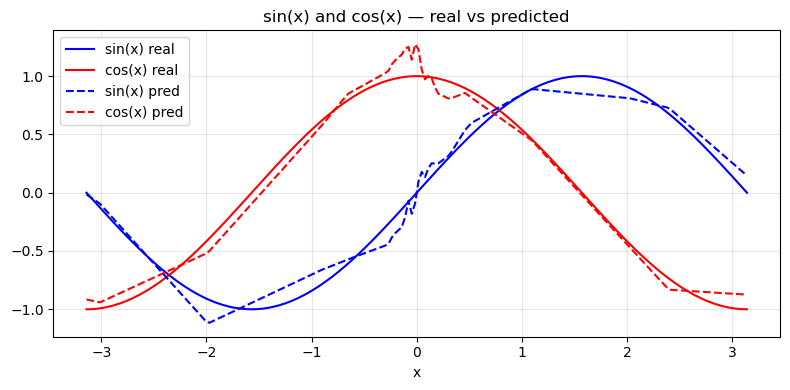

In [11]:
# Create class:
class ScaledLinear(nn.Module):

    def __init__(self, input_neurons, output_neurons):
        super().__init__()
        self.W = nn.Parameter(torch.randn(output_neurons, input_neurons))
        self.b = nn.Parameter(torch.zeros(output_neurons))
        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        return self.alpha * (torch.matmul(x, self.W.T)  + self.b)

# Create model:
model = nn.Sequential(ScaledLinear(1,32), nn.ReLU(),
                      ScaledLinear(32,16), nn.ReLU(),
                      ScaledLinear(16,2))

# Verify appearence of alpha:
print('--- Before training ---')
alphas = []
for name, parameter in model.named_parameters():
    if name.__contains__('alpha'):
        print(f'{name} --> {parameter.item()}')
        alphas.append(parameter.item())


# Loss and optimizer:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Data:
print('--- Dataset ---')
x = torch.linspace(-torch.pi, torch.pi, 200)
y1 = torch.sin(x)
y2 = torch.cos(x)

x = torch.FloatTensor(x.unsqueeze(1))
y = torch.FloatTensor(torch.stack([y1, y2], dim=1))
print(f'x.shape: {x.shape}')
print(f'y.shape: {y.shape}')

# Training Loop:
epochs = 1000
model.train()
print('--- Train ---')
for epoch in range(epochs):
    # Reset optimizer:
    optimizer.zero_grad()

    # Prediction:
    pred = model(x)

    # Loss:
    loss = loss_fn(pred, y)

    # Backprop:
    loss.backward()
    optimizer.step()
    if (epoch % 250 == 0) or (epoch == epochs -1):
        print(f'Epoch {epoch} --> loss:{loss.item():.4f}')

print('--- After training ---')
i = 0
for name, parameter in model.named_parameters():
    if name.__contains__('alpha'):
        print(f'{name} --> {parameter.item():.4f}')
        print(f'Did alpha change? --> {not (alphas[i] == parameter.item())}')
        i +=1

# Test:
model.eval()
with torch.no_grad():
    pred = model(x).numpy()

# Plot:
x_np = x.squeeze().numpy()
plt.figure(figsize=(8, 4))
plt.plot(x_np, y1.numpy(),  color='blue',   label='sin(x) real')
plt.plot(x_np, y2.numpy(),  color='red',    label='cos(x) real')
plt.plot(x_np, pred[:, 0],  color='blue',   label='sin(x) pred', linestyle='--')
plt.plot(x_np, pred[:, 1],  color='red',    label='cos(x) pred', linestyle='--')
plt.legend()
plt.title('sin(x) and cos(x) — real vs predicted')
plt.xlabel('x')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 🎌<span style='color:rgb(10,110,217)'><u>**Summary**</u></span>

<div align='center'>

| Topic | Key Concept | PyTorch API |
|---|---|---|
| Model definition | Subclass `nn.Module`, implement `forward` | `nn.Module`, `nn.Linear` |
| Regression | MSE loss, SGD/Adam | `nn.MSELoss`, `torch.optim` |
| Activation functions | Non-linearity, inductive bias | `nn.ReLU`, `nn.Tanh`, `nn.GELU`, `nn.LeakyReLU` |
| Multi-class | Logits + cross-entropy | `nn.CrossEntropyLoss` |
| Parameter inspection | Count and visualize weights | `.named_parameters()`, `.numel()` |
| Saving / loading | Persist and restore `state_dict` | `torch.save`, `torch.load` |
| Custom layers | Learnable scalars/tensors | `nn.Parameter` |
| Multi-output | Joint regression over multiple targets | Output layer with `k` units |
| Binary classification | Fused sigmoid + BCE for stability | `nn.BCEWithLogitsLoss` |
| Residual blocks | Skip connections for deep networks | Manual `out = F(x) + x` |
| Weight initialization | Break symmetry, control variance | `torch.nn.init` |
</div>